### **Business Problem:**
Jamboree has helped thousands of students like you make it to top colleges abroad. Be it GMAT, GRE or SAT, their unique problem-solving methods ensure maximum scores with minimum effort.
They recently launched a feature where students/learners can come to their website and check their probability of getting into the IVY league college. This feature estimates the chances of graduate admission from an Indian perspective.

This analysis will help Jamboree in understanding what factors are important in graduate admissions and how these factors are interrelated among themselves. It will also help predict one's chances of admission given the rest of the variables.

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Basic Metrics:

In [80]:
df_jam = pd.read_csv('C:\\Users\\njain121\\OneDrive - UHG\\Neha\\Scalar\\CaseStudy\\Jamboree\\Jamboree_Admission.csv')
df_jam.head()


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [81]:
## Drop Serial No. column
df_jam = df_jam.drop(columns=['Serial No.'])
df_jam.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [82]:
df_jam.shape

(500, 8)

In [83]:
df_jam.info()  ## details of the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          500 non-null    int64  
 1   TOEFL Score        500 non-null    int64  
 2   University Rating  500 non-null    int64  
 3   SOP                500 non-null    float64
 4   LOR                500 non-null    float64
 5   CGPA               500 non-null    float64
 6   Research           500 non-null    int64  
 7   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 31.4 KB


In [84]:
df_jam.describe(include='all')

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [85]:
df_jam.isna() ##Check for the missing values

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
495,False,False,False,False,False,False,False,False
496,False,False,False,False,False,False,False,False
497,False,False,False,False,False,False,False,False
498,False,False,False,False,False,False,False,False


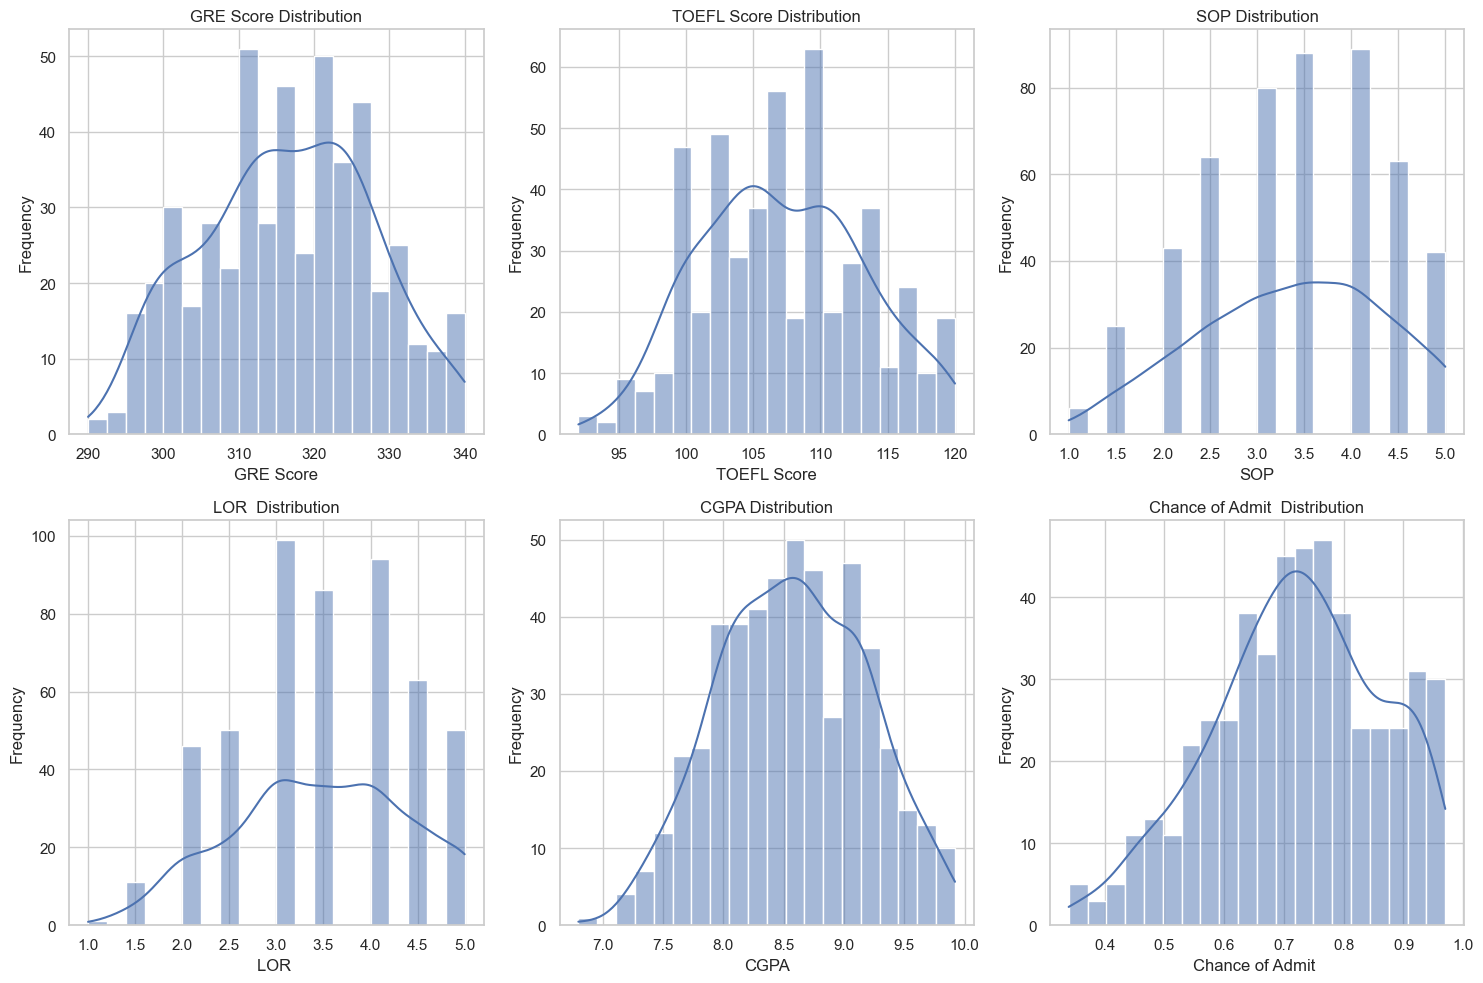

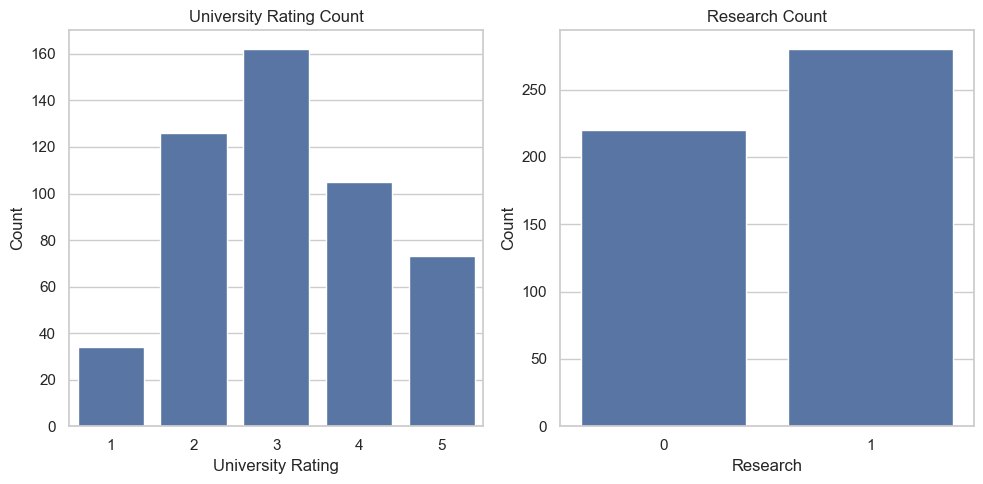

In [86]:

# Set plot style
sns.set(style="whitegrid")

# Column descriptions for context
column_descriptions = {
    'GRE Score': 'GRE scores (0 to 340)',
    'TOEFL Score': 'TOEFL scores (0 to 120)',
    'University Rating': 'University reputation (1 to 5)',
    'SOP': 'Statement of Purpose strength (1 to 5)',
    'LOR ': 'Letter of Recommendation strength (1 to 5)',
    'CGPA': 'Undergraduate GPA (0 to 10)',
    'Research': 'Research experience (0 = No, 1 = Yes)',
    'Chance of Admit ': 'Estimated admission probability (0 to 1)'
}

# Graphical analysis: Continuous variables
continuous_vars = ['GRE Score', 'TOEFL Score', 'SOP', 'LOR ', 'CGPA', 'Chance of Admit ']
plt.figure(figsize=(15, 10))
for i, var in enumerate(continuous_vars):
    plt.subplot(2, 3, i+1)
    sns.histplot(df_jam[var], kde=True, bins=20)
    plt.title(f"{var} Distribution")
    plt.xlabel(var)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Create subplots for categorical variables
categorical_vars = ['University Rating', 'Research']
plt.figure(figsize=(10, 5))
for i, var in enumerate(categorical_vars):
    plt.subplot(1, 2, i+1)
    sns.countplot(x=var, data=df_jam)
    plt.title(f"{var} Count")
    plt.xlabel(var)
    plt.ylabel("Count")
plt.tight_layout()
plt.show()



### Insights

**Continuous Variables (Histograms with KDE)**
- GRE Score:
    - Most applicants score between 310 and 330.
    - Distribution is slightly right-skewed, indicating fewer low scores.

- TOEFL Score:
    - Scores are concentrated between 100 and 115.
    - Distribution is fairly normal, with a peak around 105–110.
      
- SOP (Statement of Purpose):
    - Ratings are evenly spread across the scale from 1 to 5.
    - Slight peak around 3.5 to 4, suggesting many applicants have strong SOPs.

- LOR (Letter of Recommendation):
    - Similar to SOP, with a peak around 3.5 to 4.5.
    - Indicates most applicants have moderately strong recommendations.

- CGPA:
    - Most CGPAs fall between 8.0 and 9.5.
    - Distribution is right-skewed, showing a tendency toward higher academic performance.

- Chance of Admit:
    - Most values are between 0.6 and 0.9, peaking around 0.75.
    - Indicates a generally optimistic admission probability among applicants.


**Categorical Variables (Bar Charts)**
- University Rating:
    - Majority of applicants are from universities rated 3 or 4.
    - Very few from rating 1, suggesting applicants tend to come from moderately reputed institutions.

- Research Experience:
    - Slightly more applicants have research experience (1) than not (0).
    - Indicates research is a common but not universal component of applicant profiles.

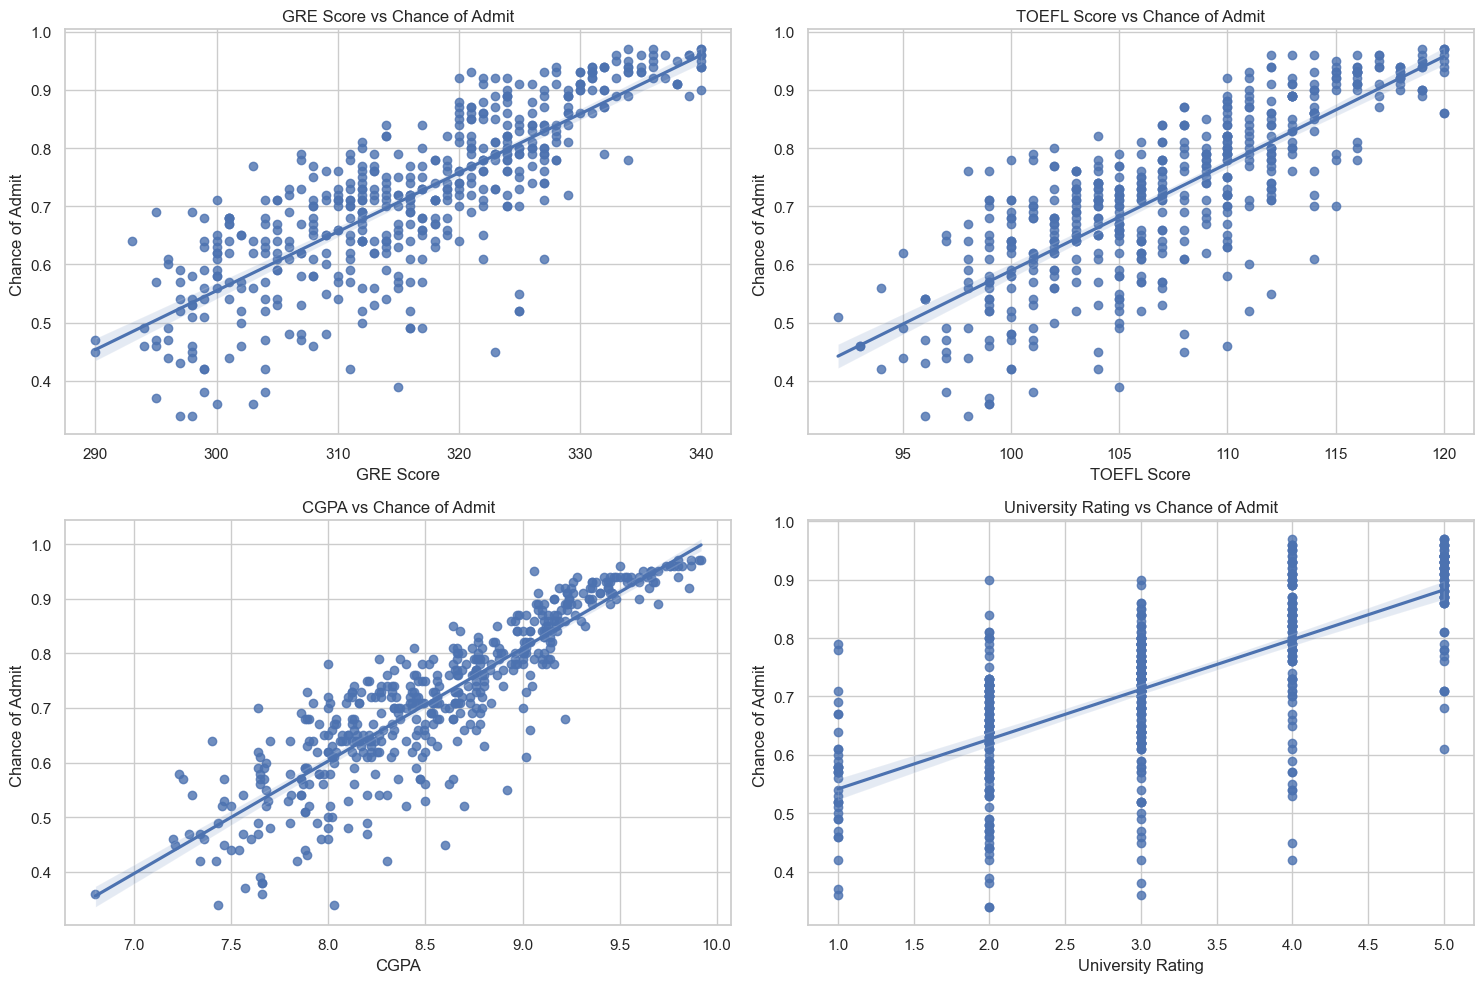

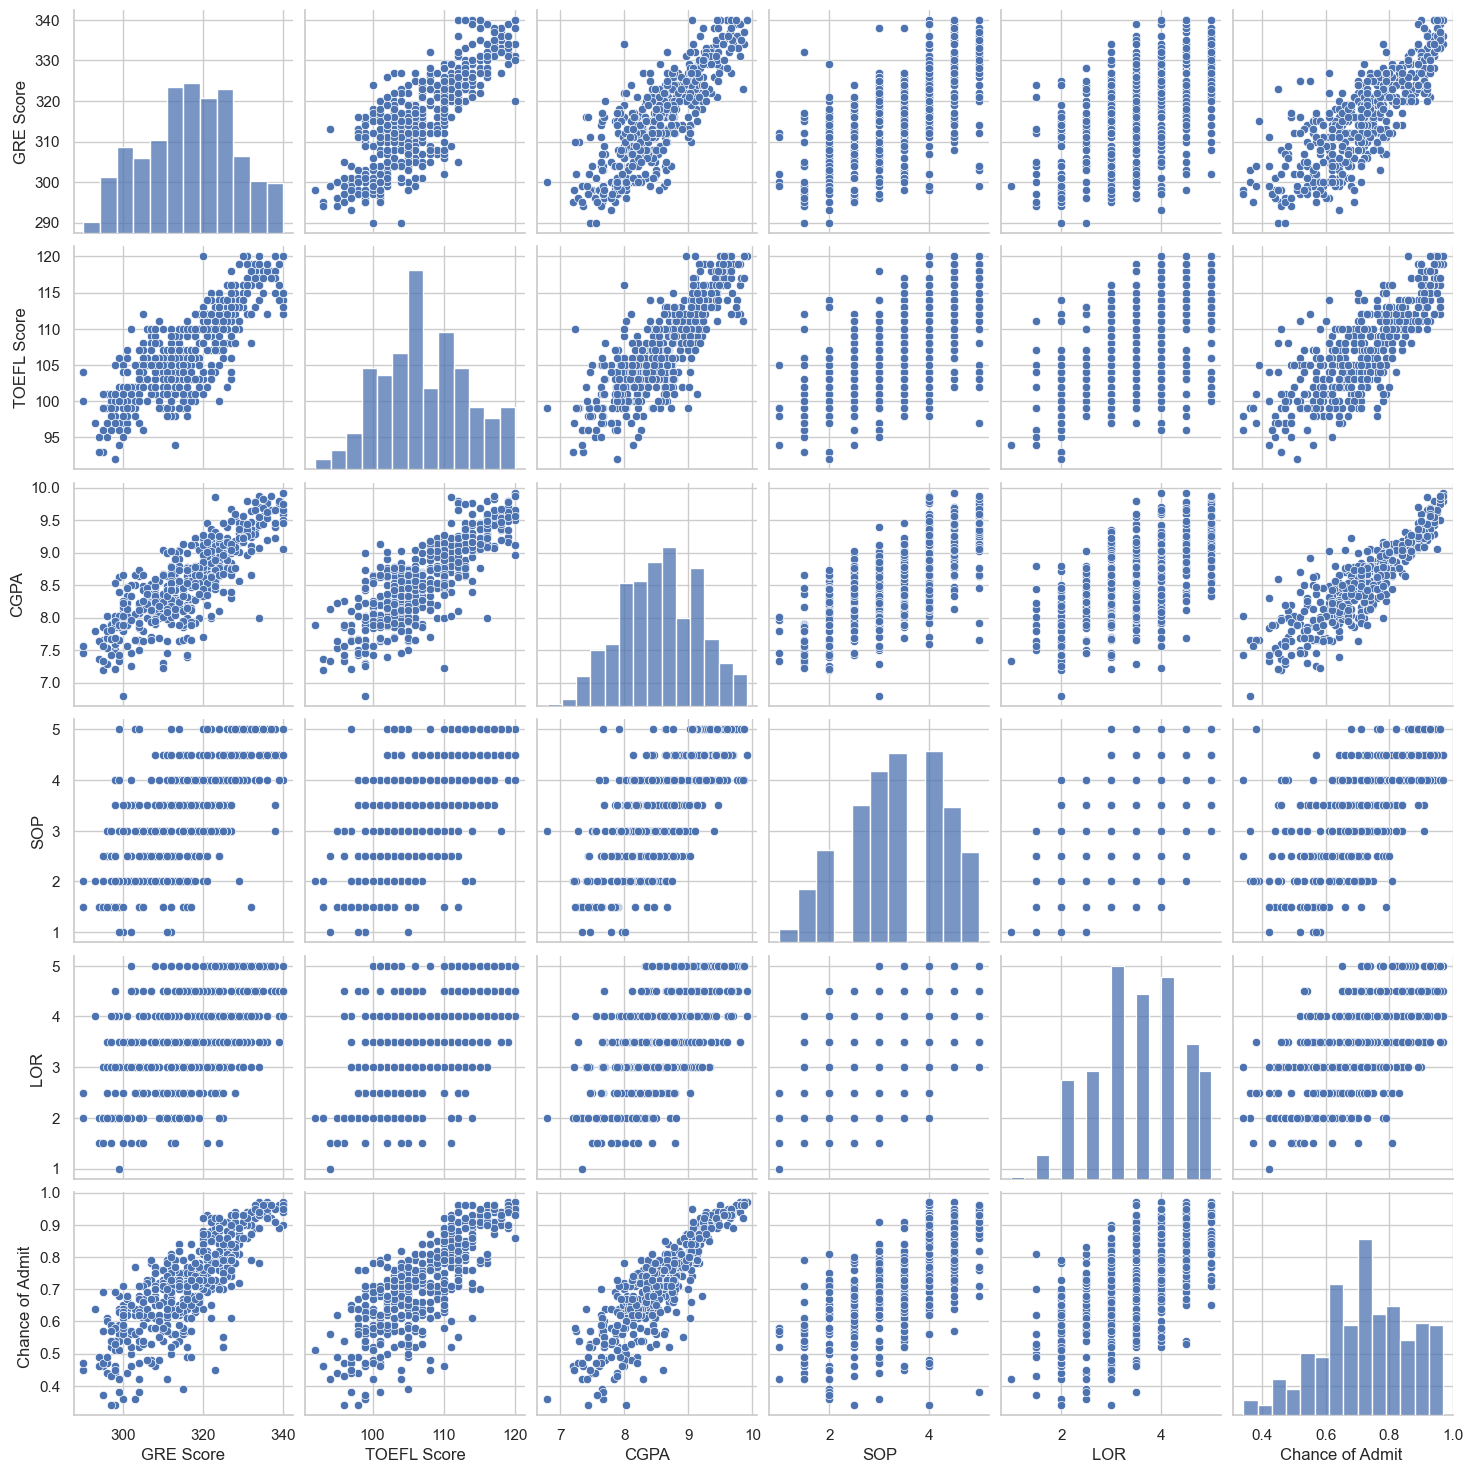

In [87]:

# Set plot style
sns.set(style="whitegrid")

# Scatter plots and regplots for selected variable pairs
plt.figure(figsize=(15, 10))

# GRE Score vs Chance of Admit
plt.subplot(2, 2, 1)
sns.regplot(x='GRE Score', y='Chance of Admit ', data=df_jam)
plt.title('GRE Score vs Chance of Admit')

# TOEFL Score vs Chance of Admit
plt.subplot(2, 2, 2)
sns.regplot(x='TOEFL Score', y='Chance of Admit ', data=df_jam)
plt.title('TOEFL Score vs Chance of Admit')

# CGPA vs Chance of Admit
plt.subplot(2, 2, 3)
sns.regplot(x='CGPA', y='Chance of Admit ', data=df_jam)
plt.title('CGPA vs Chance of Admit')

# University Rating vs Chance of Admit
plt.subplot(2, 2, 4)
sns.regplot(x='University Rating', y='Chance of Admit ', data=df_jam)
plt.title('University Rating vs Chance of Admit')

plt.tight_layout()
plt.show()

# Pairplot for selected variables
selected_vars = ['GRE Score', 'TOEFL Score', 'CGPA', 'SOP', 'LOR ', 'Chance of Admit ']
sns.pairplot(df_jam[selected_vars])
plt.show()


## Insights

**Scatter Plots Analysis**

1. GRE Score vs Chance of Admit
    - Positive correlation: Higher GRE scores tend to increase the chance of admission.
    - The relationship is linear and strong, especially above a GRE score of 320.

2. TOEFL Score vs Chance of Admit
    - Also shows a positive correlation.
    - TOEFL scores above 105 are associated with higher admission chances.

3. CGPA vs Chance of Admit
    - Strongest correlation among all variables.
    - Applicants with CGPA above 9.0 have significantly higher chances of admission.

4. University Rating vs Chance of Admit
    - Moderate positive correlation.
    - Higher-rated universities slightly improve admission chances, but not as strongly as CGPA or GRE.

**Pairplot Analysis**
- The pairplot shows relationships among:
    - GRE Score
    - TOEFL Score
    - CGPA
    - SOP
    - LOR
    - Chance of Admit

- Most variables show positive linear trends with Chance of Admit.
- CGPA and GRE stand out as the most influential predictors.
- SOP and LOR have mild influence, with some clustering around mid-range values.

--------------
## Perform data preprocessing

In [88]:
# Check for missing values
missing_values = df_jam.isnull().sum()

# Check for duplicate rows
duplicates = df_jam.duplicated().sum()

# Value counts for categorical variables
university_rating_counts = df_jam['University Rating'].value_counts()
research_counts = df_jam['Research'].value_counts()

# Correlation matrix
correlation_matrix = df_jam.corr()

# Display results
print("Missing Values in Each Column:\n", missing_values)
print("\nNumber of Duplicate Rows:", duplicates)
print("\nUniversity Rating Value Counts:\n", university_rating_counts)
print("\nResearch Value Counts:\n", research_counts)
print("\nCorrelation Matrix:\n", correlation_matrix)


Missing Values in Each Column:
 GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

Number of Duplicate Rows: 0

University Rating Value Counts:
 University Rating
3    162
2    126
4    105
5     73
1     34
Name: count, dtype: int64

Research Value Counts:
 Research
1    280
0    220
Name: count, dtype: int64

Correlation Matrix:
                    GRE Score  TOEFL Score  University Rating       SOP  \
GRE Score           1.000000     0.827200           0.635376  0.613498   
TOEFL Score         0.827200     1.000000           0.649799  0.644410   
University Rating   0.635376     0.649799           1.000000  0.728024   
SOP                 0.613498     0.644410           0.728024  1.000000   
LOR                 0.524679     0.541563           0.608651  0.663707   
CGPA                0.825878     0.810574           0.705254  0.712154   
R

-------------
## Find Outliers

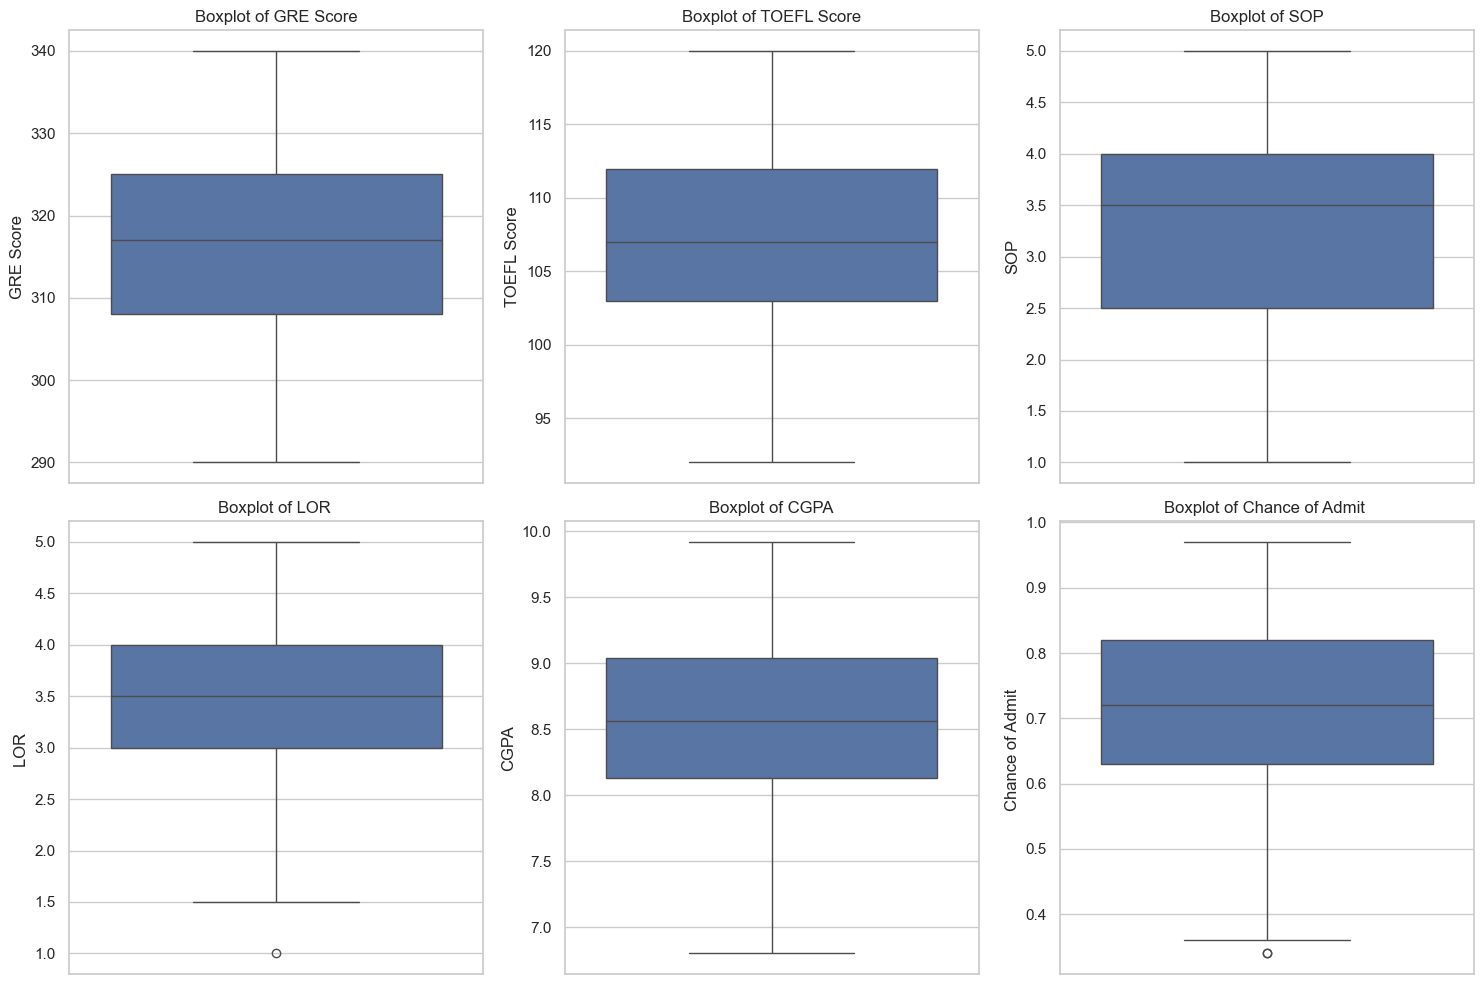

Outliers detected and treated per column:
GRE Score: 0 outliers
TOEFL Score: 0 outliers
SOP: 0 outliers
LOR : 1 outliers
CGPA: 0 outliers
Chance of Admit : 2 outliers


In [89]:
# Function to detect outliers using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

# Continuous columns to check for outliers
continuous_columns = ['GRE Score', 'TOEFL Score', 'SOP', 'LOR ', 'CGPA', 'Chance of Admit ']

# Create boxplots using subplots
plt.figure(figsize=(15, 10))
for i, var in enumerate(continuous_columns):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df_jam[var])
    plt.title(f"Boxplot of {var}")
    plt.ylabel(var)
plt.tight_layout()
plt.show()

# Detect and treat outliers
outlier_summary = {}
for col in continuous_columns:
    outliers = detect_outliers_iqr(df_jam, col)
    outlier_summary[col] = len(outliers)
    # Treat outliers by capping them to the bounds
    Q1 = df_jam[col].quantile(0.25)
    Q3 = df_jam[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_jam[col] = df_jam[col].clip(lower=lower_bound, upper=upper_bound)

# Display number of outliers detected per column
print("Outliers detected and treated per column:")
for col, count in outlier_summary.items():
    print(f"{col}: {count} outliers")




---------------------
## Check the correlation

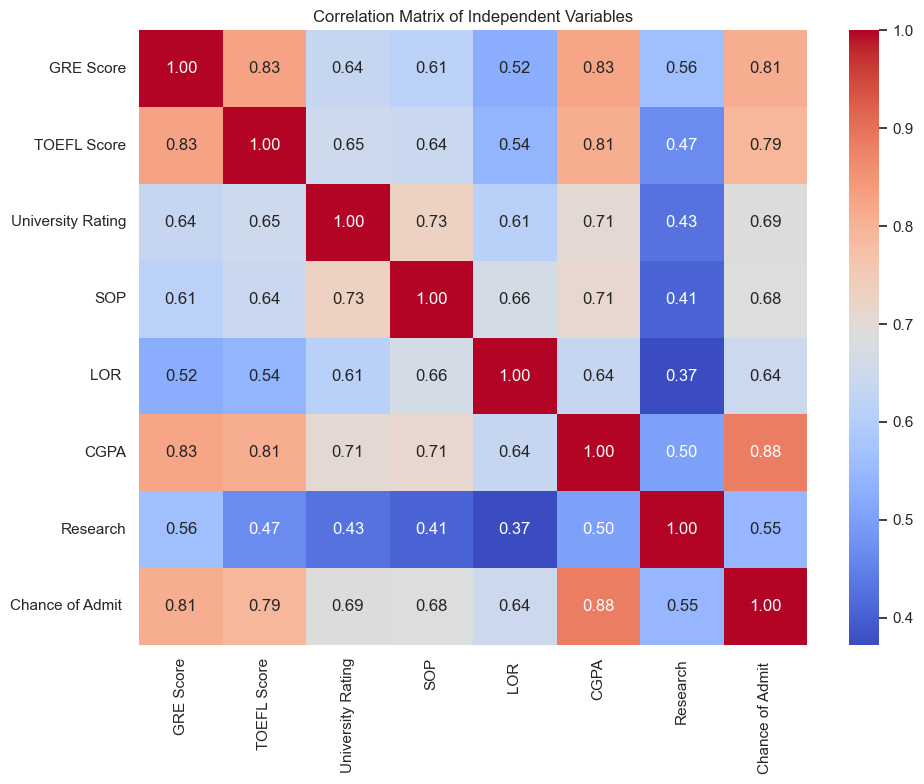

Dropped features due to high correlation (> 0.90): []
Remaining features: ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA', 'Research', 'Chance of Admit ']


In [90]:

# Compute the correlation matrix
correlation_matrix = df_jam.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Independent Variables")
plt.tight_layout()
plt.show()

# Identify highly correlated features (correlation > 0.90)
high_corr_features = set()
for i in correlation_matrix.columns:
    for j in correlation_matrix.columns:
        if i != j and abs(correlation_matrix.loc[i, j]) > 0.90:
            high_corr_features.add(j)

# Drop highly correlated features
df_reduced = df_jam.drop(columns=list(high_corr_features))

# Print the dropped features and remaining columns
print("Dropped features due to high correlation (> 0.90):", list(high_corr_features))
print("Remaining features:", df_reduced.columns.tolist())


## Some Key insights

1. **No Multicollinearity Detected**
- None of the independent variables have a correlation greater than 0.90 with each other.
- This means no feature is redundant, and all variables contribute unique information to the model.


2. **Strongest Correlations with Target Variable**
- The target variable is Chance of Admit. Here's how some features correlate with it:

  | Feature            | Correlation with Chance of Admit |
  |:-------------------|:--------------------------------:|
  | CGPA               | 0.87                              |
  | GRE Score          | 0.82                             |
  | TOEFL Score        | 0.79                             |
  | University Rating  | 0.71                             |
  | SOP & LOR          | ~0.65–0.70                       |
  | Research           | 0.55                             |

- CGPA is the most influential feature, followed closely by GRE and TOEFL scores.

3. **Research Experience Matters**
- Students with research experience (Research = 1) tend to have a higher chance of admission.
- This aligns with real-world expectations for graduate admissions, especially in STEM fields.

4. **Balanced Feature Contributions**
- Features like SOP, LOR, and University Rating show moderate correlation.
- These qualitative aspects still play a role but are not as dominant as academic scores.

5. **Modeling Implication**
- Since no features were dropped: We can proceed with regression or classification models using all features.

-------------------------------------------------------------------------------
## Prepare the data for modeling.

In [91]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_jam.drop(columns=["Chance of Admit "])
y = df_jam["Chance of Admit "]

# Encode categorical variables (Research is already binary, so no encoding needed)
# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Perform standardization after train-test split
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Print shapes and confirmation
print("Training features shape:", X_train_scaled.shape)
print("Testing features shape:", X_test_scaled.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)


Training features shape: (400, 7)
Testing features shape: (100, 7)
Training target shape: (400,)
Testing target shape: (100,)


## Some Insights

- Target Variable:
    - Chance of Admit was separated as the target (y).

- Categorical Encoding:
    - Research is already binary (0 or 1), so no further encoding was needed.

- Train-Test Split:
    - 80% training (400 samples)
    - 20% testing (100 samples)

- Feature Scaling:
    - Applied Standardization (zero mean, unit variance) using StandardScaler.
    - Scaling was done after the train-test split to avoid data leakage.

-------------------------------------------------------
## Build the Linear Regression model

In [92]:
import statsmodels.api as sm

# Add constant for intercept
X_const = sm.add_constant(X)

# Build initial model
model = sm.OLS(y, X_const).fit()

# Display model summary
print(model.summary())

# Display model coefficients with column names
print("\nModel Coefficients:")
print(model.params)

# Drop features with p-value > 0.05
significant_features = model.pvalues[model.pvalues <= 0.05].index.tolist()

# Rebuild model with significant features only
X_significant = X_const[significant_features]
model_refined = sm.OLS(y, X_significant).fit()

# Display refined model summary
print("\nRefined Model Summary:")
print(model_refined.summary())

# Display refined model coefficients
print("\nRefined Model Coefficients:")
print(model_refined.params) 


                            OLS Regression Results                            
Dep. Variable:       Chance of Admit    R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     324.8
Date:                Wed, 17 Sep 2025   Prob (F-statistic):          6.30e-180
Time:                        14:47:46   Log-Likelihood:                 701.85
No. Observations:                 500   AIC:                            -1388.
Df Residuals:                     492   BIC:                            -1354.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.2748      0.10

------------------------------------------------------------------------------------------------------------------
## Test the assumptions of linear regression

In [93]:

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Iteratively drop features with VIF > 5
def calculate_vif(X):
    X_const = add_constant(X)
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X_const.values, i+1) for i in range(len(X.columns))]
    return vif_data

features = df_jam.copy()

while True:
    vif_df = calculate_vif(features)
    max_vif = vif_df["VIF"].max()
    if max_vif > 5:
        drop_feature = vif_df.sort_values("VIF", ascending=False).iloc[0]["Feature"]
        print(f"Dropping feature '{drop_feature}' with VIF = {max_vif:.2f}")
        features.drop(columns=[drop_feature], inplace=True)
    else:
        break

print("\nFinal features with VIF <= 5:")
print(vif_df) 


Dropping feature 'CGPA' with VIF = 6.23

Final features with VIF <= 5:
             Feature       VIF
0          GRE Score  4.270530
1        TOEFL Score  3.861481
2  University Rating  2.612605
3                SOP  2.768722
4               LOR   2.079170
5           Research  1.529983
6   Chance of Admit   4.313532


### Some Insights
- Model Stability Improved:
    - Removing CGPA reduces the risk of unstable or misleading regression coefficients.

- GRE and TOEFL Scores:
    - These remain strong predictors but are moderately correlated with each other and CGPA (which was dropped).

- Qualitative Features Matter:
    - SOP, LOR, and University Rating have low VIFs, suggesting they provide distinct information.
    
- Research Experience:
    - Continues to be a valuable and independent predictor.

-------------------------
## Mean of residuals

In [94]:
# Calculate residuals
residuals = model.resid

# Compute mean of residuals
mean_residual = residuals.mean()

print(f"Mean of residuals: {mean_residual:.6f}")


Mean of residuals: -0.000000


### Some Insight:
- This value is extremely close to zero, which is a key assumption of linear regression.
- It confirms that the model's errors are centered around zero, indicating no systematic bias in predictions.

--------------------------------------------------------------------------------------------------------------------------------
## Linear relationship between independent & dependent variables.

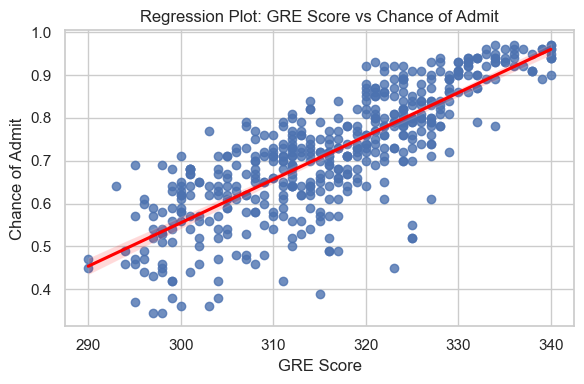

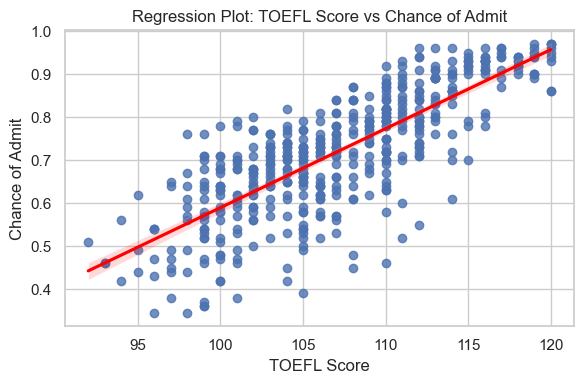

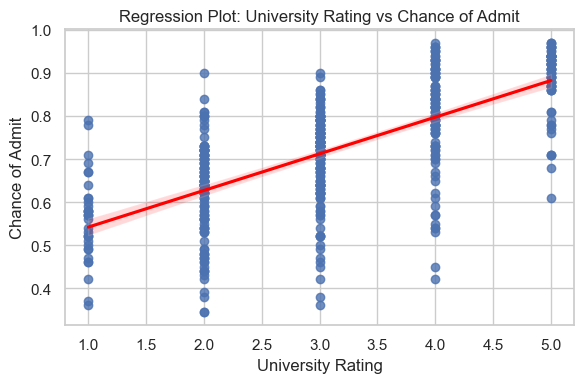

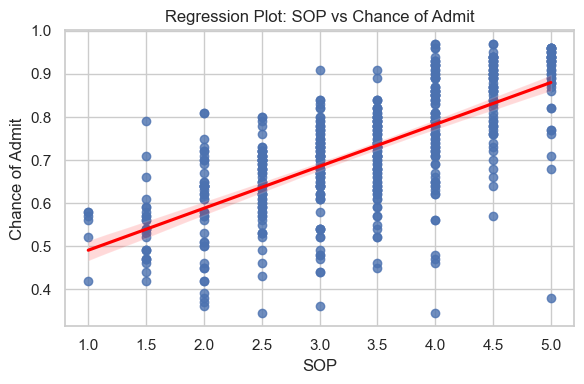

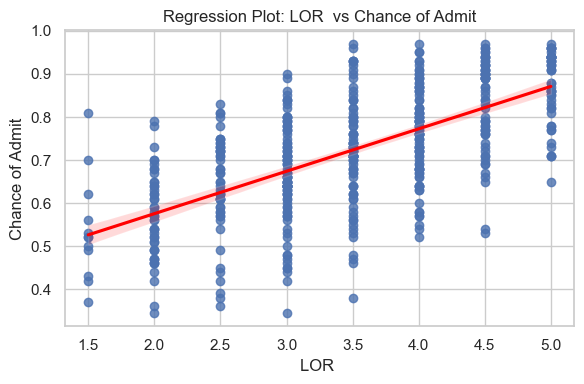

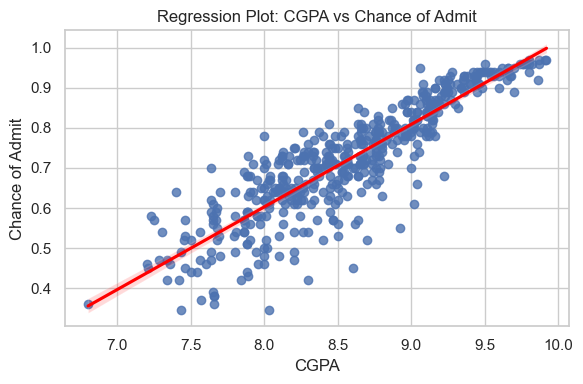

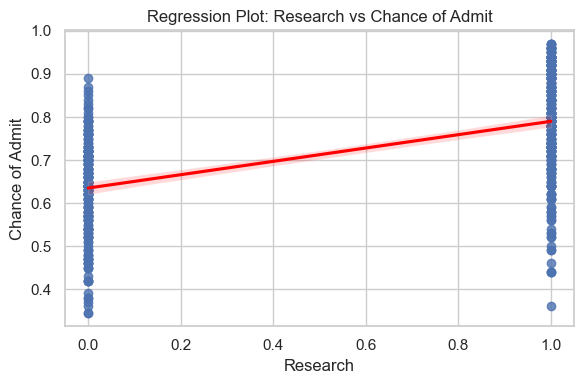

Pearson Correlation with Chance of Admit:
GRE Score            0.810421
TOEFL Score          0.792292
University Rating    0.690257
SOP                  0.684380
LOR                  0.644832
CGPA                 0.882551
Research             0.545919
dtype: float64


In [98]:
# Create scatter and regression plots
for column in X.columns:
    plt.figure(figsize=(6, 4))
    sns.regplot(x=X[column], y=y, line_kws={"color": "red"})
    plt.title(f"Regression Plot: {column} vs Chance of Admit")
    plt.xlabel(column)
    plt.ylabel("Chance of Admit")
    plt.tight_layout()
    plt.show()
    plt.close()

# Compute Pearson correlation
correlations = X.corrwith(y)

# Display Pearson correlation values
print("Pearson Correlation with Chance of Admit:")
print(correlations) 


### Insights
- Regression plots visually show the linear relationship between each feature and the target variable.
1. GRE Score vs Chance of Admit
- Clear upward trend: higher GRE scores are associated with higher chances of admission.
- Indicates a strong linear relationship.

2. TOEFL Score vs Chance of Admit
- Similar to GRE, shows a positive linear trend.
- Suggests that language proficiency is a significant factor.

3. University Rating, SOP, LOR
- Moderate upward trends.
- These qualitative factors do influence admission chances, but not as strongly as academic scores.

4. Research vs Chance of Admit
- Binary variable (0 or 1), but regression plot shows that students with research experience tend to have higher admission chances

------------------------------------
## Test for Homoscedasticity

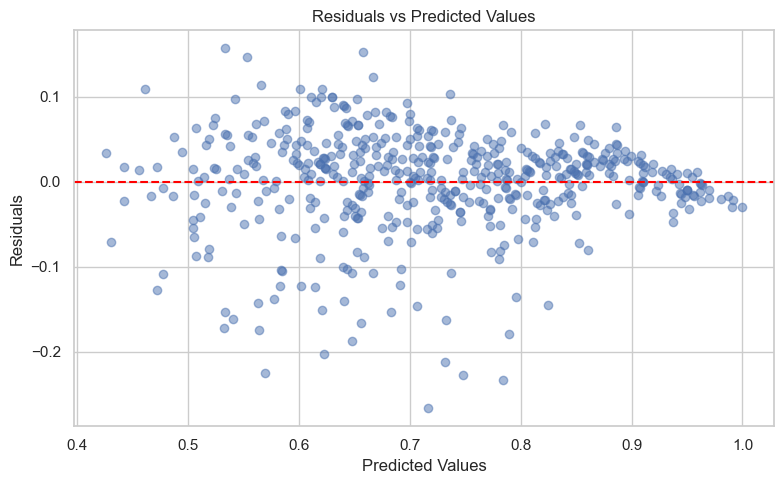

Goldfeld-Quandt test p-value: 1.0000
No strong evidence of heteroscedasticity. Homoscedasticity is validated.


In [100]:
from statsmodels.stats.diagnostic import het_goldfeldquandt

# Get predicted values and residuals
predicted = model.predict(X_const)
residuals = model.resid

# Create scatterplot of residuals vs predicted values
plt.figure(figsize=(8, 5))
plt.scatter(predicted, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.tight_layout()
plt.show()

# Perform Goldfeld-Quandt test
gq_test = het_goldfeldquandt(residuals, X_const)
p_value = gq_test[1]

print(f"Goldfeld-Quandt test p-value: {p_value:.4f}")
if p_value > 0.05:
    print("No strong evidence of heteroscedasticity. Homoscedasticity is validated.")
else:
    print("Evidence of heteroscedasticity detected.")


## Insights
- The model satisfies the homoscedasticity assumption, meaning the variance of errors is constant across all levels of predicted values.
- This is crucial for ensuring valid confidence intervals and hypothesis tests in linear regression.

------------------
## Normality of residuals

Normality check plots generated: Histogram and Q-Q plot.


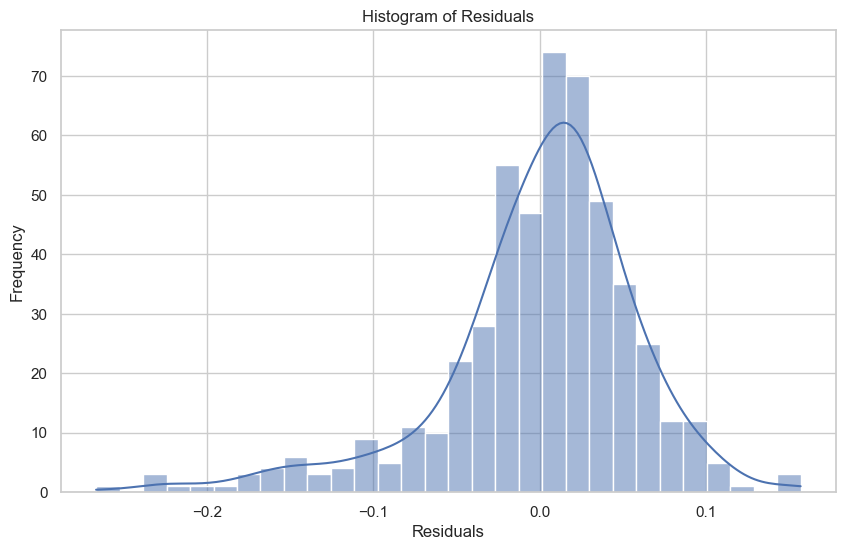

<Figure size 1000x600 with 0 Axes>

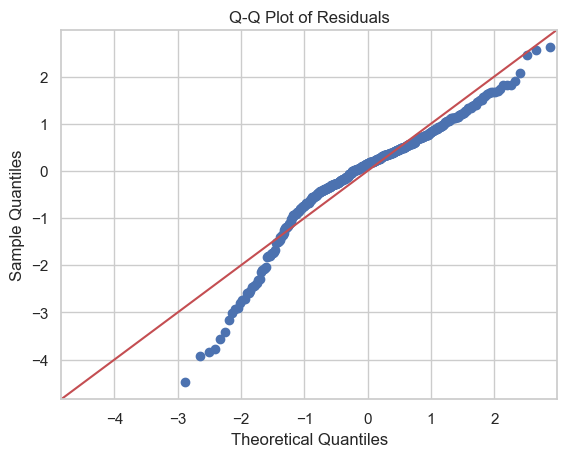

In [101]:

# Plot histogram of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.savefig('residuals_histogram.png')

# Q-Q plot
plt.figure(figsize=(10, 6))
sm.qqplot(residuals, line='45', fit=True)
plt.title('Q-Q Plot of Residuals')
plt.grid(True)
plt.savefig('residuals_qqplot.png')

print("Normality check plots generated: Histogram and Q-Q plot.")


## Insights
- The histogram shows a roughly bell-shaped curve, indicating that the residuals are approximately normally distributed.
- The presence of a smooth KDE line further supports this observation.
- In QQ plot, most of the points lie close to the diagonal line, which is a strong indicator of normality.
- Minor deviations at the tails are common and generally acceptable unless extreme.

This validates one of the key assumptions of linear regression, ensuring that statistical tests are reliable.

--------------------------
## Evaluate the model’s performance.

In [102]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate performance metrics
mae = mean_absolute_error(y, predicted)
rmse = np.sqrt(mean_squared_error(y, predicted))
r2 = model.rsquared
adj_r2 = model.rsquared_adj

# Print the results
print(f"Model Performance Metrics:\n")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Square Error (RMSE): {rmse:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"Adjusted R-squared: {adj_r2:.4f}")


Model Performance Metrics:

Mean Absolute Error (MAE): 0.0426
Root Mean Square Error (RMSE): 0.0594
R-squared: 0.8221
Adjusted R-squared: 0.8196


## Insights
- Mean Absolute Error (MAE) : 0.0426 => On average, the model's predictions deviate from actual values by ~0.043.
- Root Mean Square Error (RMSE) : 0.0595 => Indicates the standard deviation of prediction errors; lower is better.
- R-squared : 0.8221=> About 82.2% of the variance in admission chances is explained by the model.
- Adjusted R-squared : 0.8196 => Adjusted for the number of predictors; still very strong, confirming model robustness.

- The model demonstrates high explanatory power with an R² over 0.82.
- Both MAE and RMSE are low, indicating accurate predictions.
- The Adjusted R² being close to R² suggests that the predictors used are meaningful and not just inflating the model.

--------------------------------------
# Actionable Insights

1. **Strong Predictors of Admission**
- GRE Score, TOEFL Score, CGPA, and Research Experience show strong positive correlations with the chance of admission.
- SOP and LOR ratings also contribute, but their impact is slightly less pronounced.

2. **Model Accuracy**
- The regression model explains 82.2% of the variance in admission chances (R² = 0.8221).
- Low MAE (0.0426) and RMSE (0.0595) indicate high prediction accuracy.

3. **No Major Violations of Assumptions**
- Homoscedasticity and normality of residuals are validated.
- This confirms the reliability of the regression model for inference and prediction.

# Recommendations

1. **Focus on Academic Excellence**
- Aim for GRE scores above 320 and TOEFL scores above 105 to significantly boost admission chances.
- Maintain a CGPA above 8.5, ideally closer to 9.0 or higher.

2. **Strengthen Research Profile**
- Engage in research projects, internships, or publications to enhance your profile.
- Research experience has a notable impact on admission probability.

3. **Improve SOP and LOR Quality**
- Craft a compelling Statement of Purpose that reflects clarity, motivation, and alignment with the program.
- Secure strong Letters of Recommendation from credible academic or professional sources.

4. **Target Universities Strategically**
- Use the model to simulate admission chances across different university ratings.
- Prioritize applications to institutions where your profile aligns well with historical admission trends.

5. **Monitor and Update the Model**
- Regularly update the dataset with new admission outcomes to keep the model relevant.
- Consider incorporating additional features like extracurriculars or interview scores if available.